# S3  Preprocessing & EDA (Exploratory Data Analysis)

## Strategija sa dva dataseta

| | Dataset A | Dataset B |
|---|---|---|
| **Naziv** | Indicators of Heart Disease (CDC 2022) | Heart Failure Prediction |
| **Izvor** | CDC BRFSS Survey | Cleveland + Hungarian + Switzerland + VA |
| **Veličina** | ~400k ispitanika | 918 pacijenata |
| **Tip** | Survey / populacijski | Klinički |
| **Target** | `HadHeartAttack` | `HeartDisease` |
| **Uloga** | Glavni dataset — puna evaluacija | Validacijski — provjera robusnosti metodologije |

**Pristup:** Isti pipeline, isti algoritmi, ista XAI metodologija primjenjuju se na oba dataseta **nezavisno**. Poređenje SHAP feature rangova između dataseta je jedan od ključnih doprinosa rada.

### Šta radimo u ovom notebooku:
1. Učitavanje podataka
2. Provjera kvaliteta (missing values, duplikati)
3. Čišćenje podataka
4. Enkodiranje (tekst → brojevi)
5. Normalizacija
6. EDA vizualizacije

## Setup - Import biblioteka i konfiguracija

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from dotenv import load_dotenv
import os
import subprocess
import pickle

# SKLEARN
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split

# IMBALANCED
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

load_dotenv()

SEED = 42
np.random.seed(SEED)

# VISUAL STYLE
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

CLR_NEG = '#4C9BE8'
CLR_POS = '#E8594C'

PALETTE = {'negative': '#4C9BE8', 'positive': '#E8594C'}

# OUTPUT FOLDER
os.makedirs('figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

print('Sve biblioteke uspješno učitane! Setup završen. Seed:', SEED)

Sve biblioteke uspješno učitane! Setup završen. Seed: 42


## 1. Učitavanje podataka

In [2]:
kaggle_token = os.getenv("KAGGLE_API_TOKEN")

if not kaggle_token:
    raise ValueError("KAGGLE_API_TOKEN nije pronađen u .env fajlu!")

os.environ["KAGGLE_API_TOKEN"] = kaggle_token

subprocess.run(['pip', 'install', '-q', 'kaggle', 'imbalanced-learn'])

# Download dataseta
subprocess.run([
    'kaggle', 'datasets', 'download',
    '-d', 'kamilpytlak/personal-key-indicators-of-heart-disease',
    '--unzip'
])

subprocess.run([
    'kaggle', 'datasets', 'download',
    '-d', 'fedesoriano/heart-failure-prediction',
    '--unzip'
])

print('Dataseti preuzeti.')

Dataseti preuzeti.


In [3]:
# UČITAVANJE 

# Dataset A - CDC 2022 (veliki, survey podaci)
df_a_raw = pd.read_csv('2022/heart_2022_with_nans.csv')

# Dataset B - Heart Failure Prediction (mali, klinički)
df_b_raw = pd.read_csv('heart.csv')

# Kratki pregled
for name, df in [('Dataset A', df_a_raw), ('Dataset B', df_b_raw)]:
    print(f'\n{"="*50}')
    print(f'{name}')
    print(f'{"="*50}')
    print(f'Redovi: {df.shape[0]:,}')
    print(f'Kolone: {df.shape[1]}')
    print(f'Kolone: {list(df.columns)}')
    print(f'Tipovi:')
    print(df.dtypes.to_string(index=True))


Dataset A
Redovi: 445,132
Kolone: 40
Kolone: ['State', 'Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos']
Tipovi:
State                         object
Sex                           object
GeneralHealth                 object
PhysicalHealthDays           float64
MentalHealthDays             float64
LastCheckupTime               object
PhysicalActivit

In [4]:
def quality_report(df, name):
    """Kompletan izvještaj o kvalitetu podataka."""
    print(f'\n{"="*60}')
    print(f' QUALITY REPORT — {name}')
    print(f'{"="*60}')
    print(f'Dimenzije: {df.shape[0]:,} redova × {df.shape[1]} kolona')
    print(f'Duplikati: {df.duplicated().sum():,}')
    print(f'Ukupno missing values: {df.isnull().sum().sum():,}')

    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing):
        print(f'\nKolone s missing values:')
        for col, cnt in missing.items():
            pct = cnt / len(df) * 100
            bar = '█' * int(pct / 2)
            print(f'{col:<35} {cnt:>7,} ({pct:5.1f}%) {bar}')
    else:
        print('Nema missing values.')

    num_cols = df.select_dtypes(include='number').columns.tolist()
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    print(f'\n Numeričke kolone ({len(num_cols)}): {num_cols}')
    print(f'Kategoričke kolone ({len(cat_cols)}): {cat_cols}')
    print(f'{"="*60}')

## 2. Dataset A — CDC Indicators of Heart Disease (2022)

### 2.1 Provjera kvaliteta podataka

In [5]:
quality_report(df_a_raw, 'Dataset A - CDC 2022')


 QUALITY REPORT — Dataset A - CDC 2022
Dimenzije: 445,132 redova × 40 kolona
Duplikati: 157
Ukupno missing values: 902,665

Kolone s missing values:
TetanusLast10Tdap                    82,516 ( 18.5%) █████████
PneumoVaxEver                        77,040 ( 17.3%) ████████
HIVTesting                           66,127 ( 14.9%) ███████
ChestScan                            56,046 ( 12.6%) ██████
CovidPos                             50,764 ( 11.4%) █████
HighRiskLastYear                     50,623 ( 11.4%) █████
BMI                                  48,806 ( 11.0%) █████
FluVaxLast12                         47,121 ( 10.6%) █████
AlcoholDrinkers                      46,574 ( 10.5%) █████
WeightInKilograms                    42,078 (  9.5%) ████
ECigaretteUsage                      35,660 (  8.0%) ████
SmokerStatus                         35,462 (  8.0%) ███
HeightInMeters                       28,652 (  6.4%) ███
DifficultyErrands                    25,656 (  5.8%) ██
DifficultyConcentrating

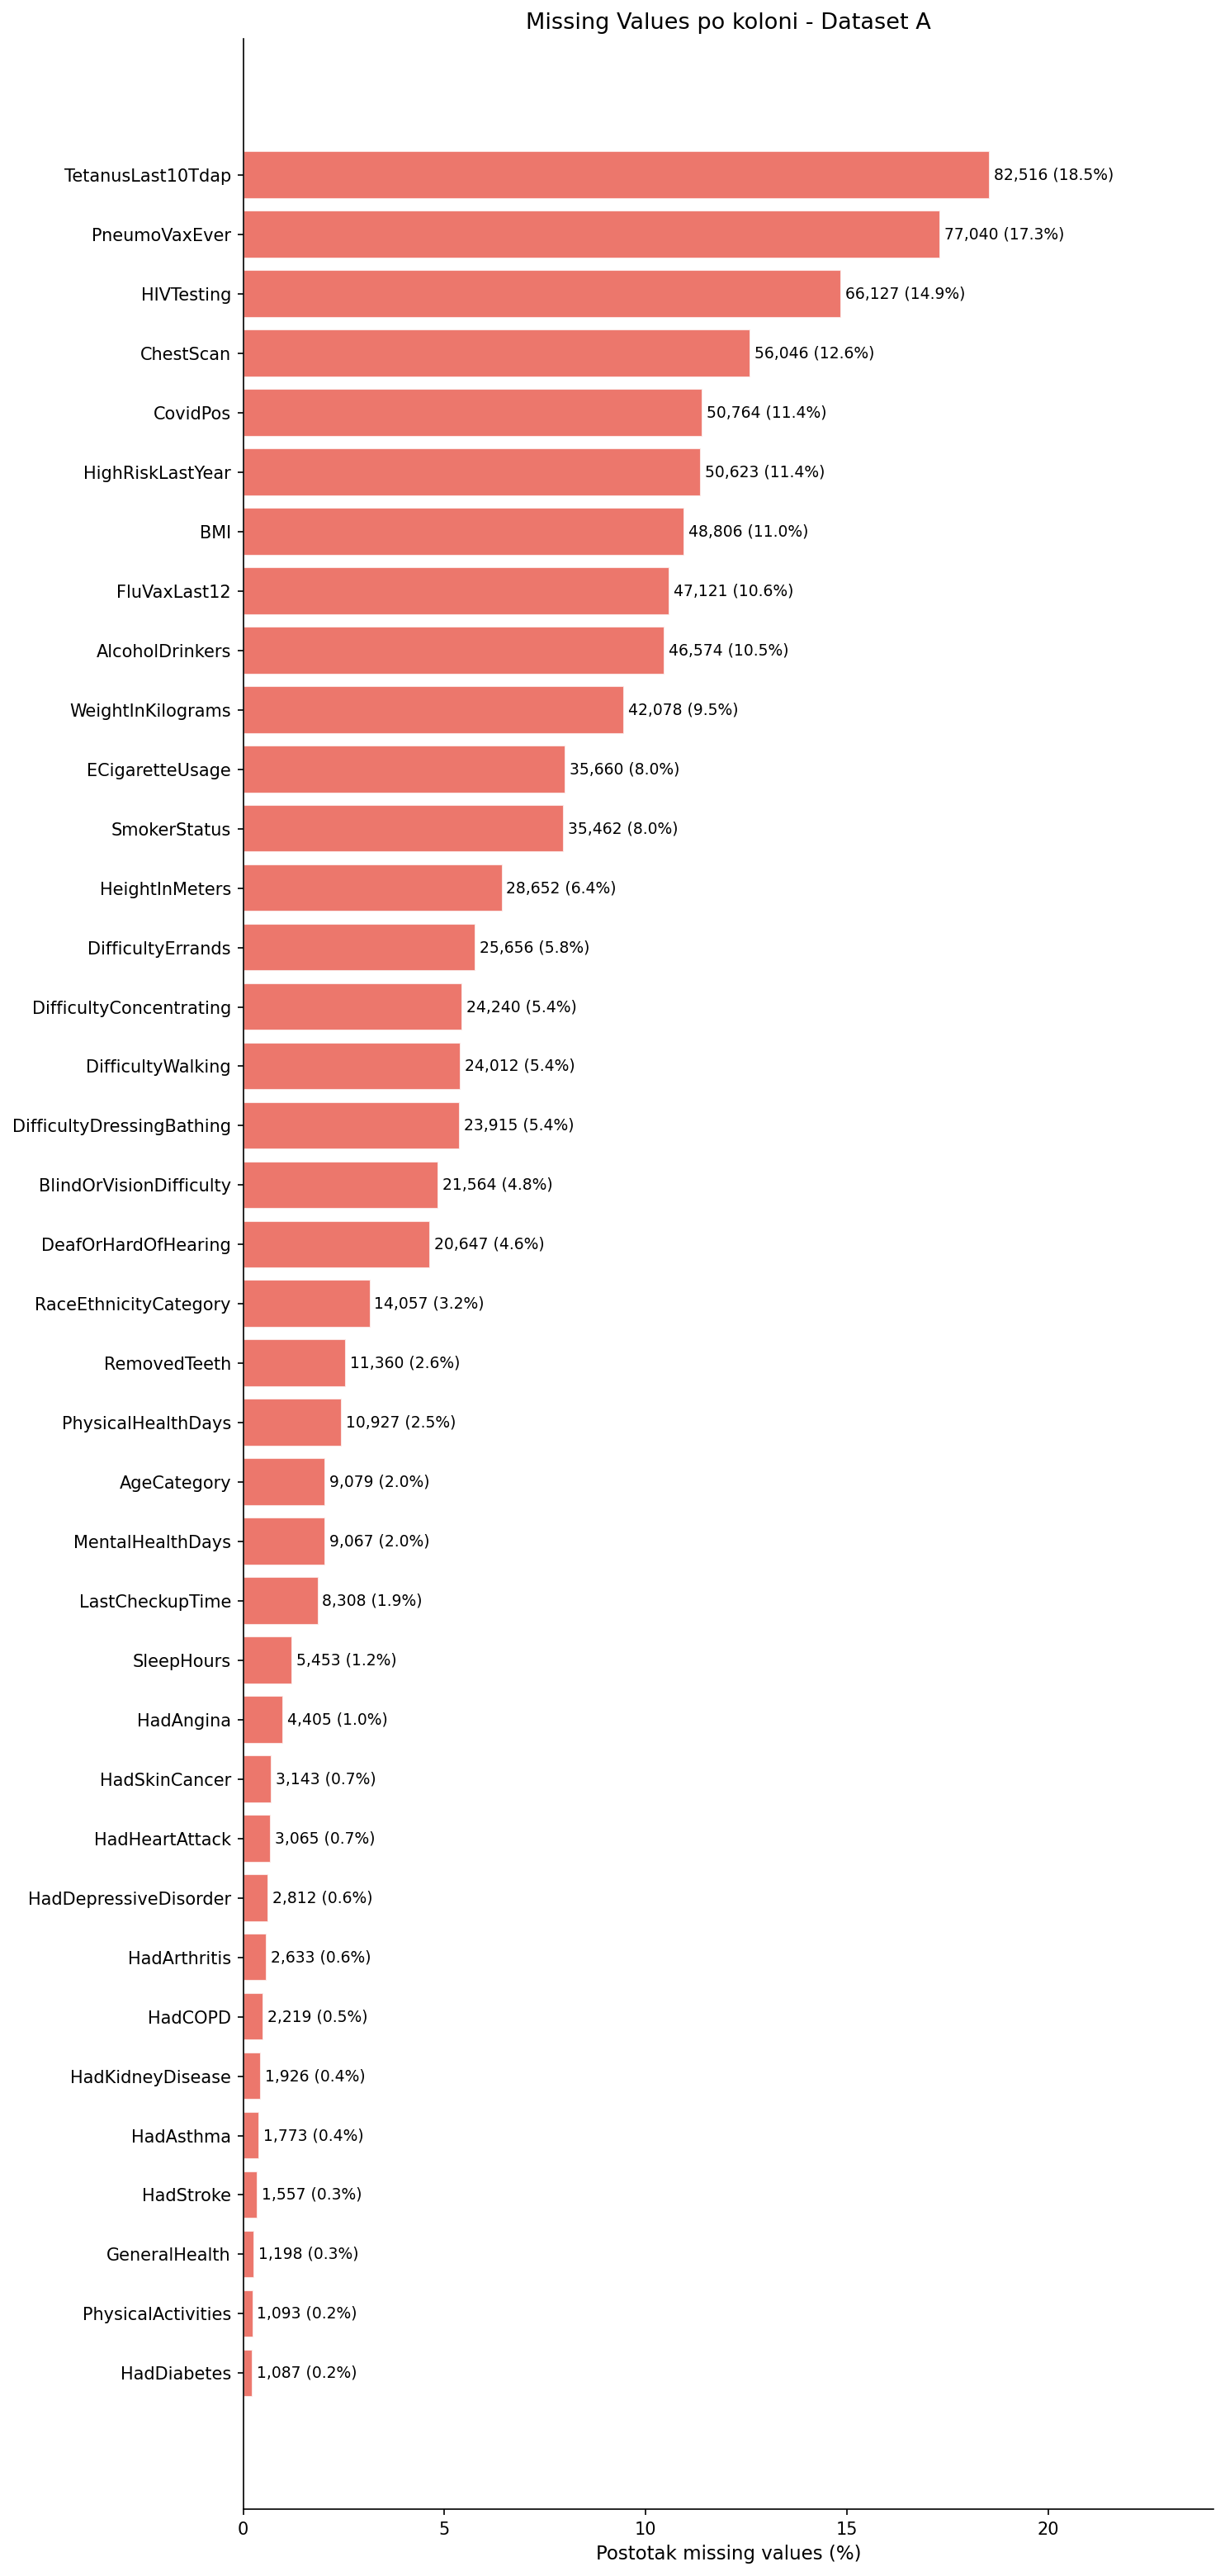

In [7]:
# Vizualizacija missing values
missing_a = df_a_raw.isnull().sum()
missing_a = missing_a[missing_a > 0].sort_values(ascending=True)

if len(missing_a) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_a) * 0.55)))
    bars = ax.barh(missing_a.index, missing_a.values / len(df_a_raw) * 100, 
                   color='#E8594C', alpha=0.82, edgecolor='white')
    ax.set_xlabel('Postotak missing values (%)')
    ax.set_title('Missing Values po koloni - Dataset A', fontsize=13)
    for bar, val in zip(bars, missing_a.values):
        pct = val / len(df_a_raw) * 100
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)
    ax.set_xlim(0, missing_a.max() / len(df_a_raw) * 130)
    plt.tight_layout()
    plt.savefig('figures/A_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Dataset A nema missing values.')

### 2.2 Čišćenje podataka

In [8]:
df_a = df_a_raw.copy()

# 1. Uklanjanje duplikata
before = len(df_a)
df_a = df_a.drop_duplicates()
print(f'Duplikati uklonjeni: {before - len(df_a):,}')
print(f'Preostalo redova: {len(df_a):,}')

# 2. Popunjavanje missing values
# Numeričke: median (robustno na outliere)
# Kategoričke: modus (najčešća vrijednost)
print('\nPopunjavanje missing values:')
for col in df_a.select_dtypes(include='number').columns:
    n_missing = df_a[col].isnull().sum()
    if n_missing > 0:
        med = df_a[col].median()
        df_a[col] = df_a[col].fillna(med)
        print(f'[NUM] {col:<30}: median = {med:.3f} ({n_missing} popunjeno)')

for col in df_a.select_dtypes(include='object').columns:
    n_missing = df_a[col].isnull().sum()
    if n_missing > 0:
        mod = df_a[col].mode()[0]
        df_a[col] = df_a[col].fillna(mod)
        print(f'[CAT] {col:<30}: modus = "{mod}" ({n_missing} popunjeno)')

print(f'\nMissing values nakon čišćenja: {df_a.isnull().sum().sum()}')
print(f'Finalni dataset A: {df_a.shape[0]:,} × {df_a.shape[1]}')

Duplikati uklonjeni: 157
Preostalo redova: 444,975

Popunjavanje missing values:
[NUM] PhysicalHealthDays            : median = 0.000 (10922 popunjeno)
[NUM] MentalHealthDays              : median = 0.000 (9062 popunjeno)
[NUM] SleepHours                    : median = 7.000 (5448 popunjeno)
[NUM] HeightInMeters                : median = 1.700 (28505 popunjeno)
[NUM] WeightInKilograms             : median = 80.740 (41931 popunjeno)
[NUM] BMI                           : median = 27.440 (48659 popunjeno)
[CAT] GeneralHealth                 : modus = "Very good" (1193 popunjeno)
[CAT] LastCheckupTime               : modus = "Within past year (anytime less than 12 months ago)" (8301 popunjeno)
[CAT] PhysicalActivities            : modus = "Yes" (1088 popunjeno)
[CAT] RemovedTeeth                  : modus = "None of them" (11355 popunjeno)
[CAT] HadHeartAttack                : modus = "No" (3060 popunjeno)
[CAT] HadAngina                     : modus = "No" (4400 popunjeno)
[CAT] HadStroke   

### 2.3 Analiza ciljne varijable (Class Distribution)

Vrijednosti u targetu: ['No' 'Yes']
Konvertovano: Yes1->, No->0
Target: HadHeartAttack
Distribucija klasa:
0 (Nema srčane bolesti): 419,867 (94.4%)
1 (Srčana bolest): 25,108 (5.6%)
Omjer klasa: 16.7:1
Class imbalance detektovan. Primijenit ćemo SMOTE.


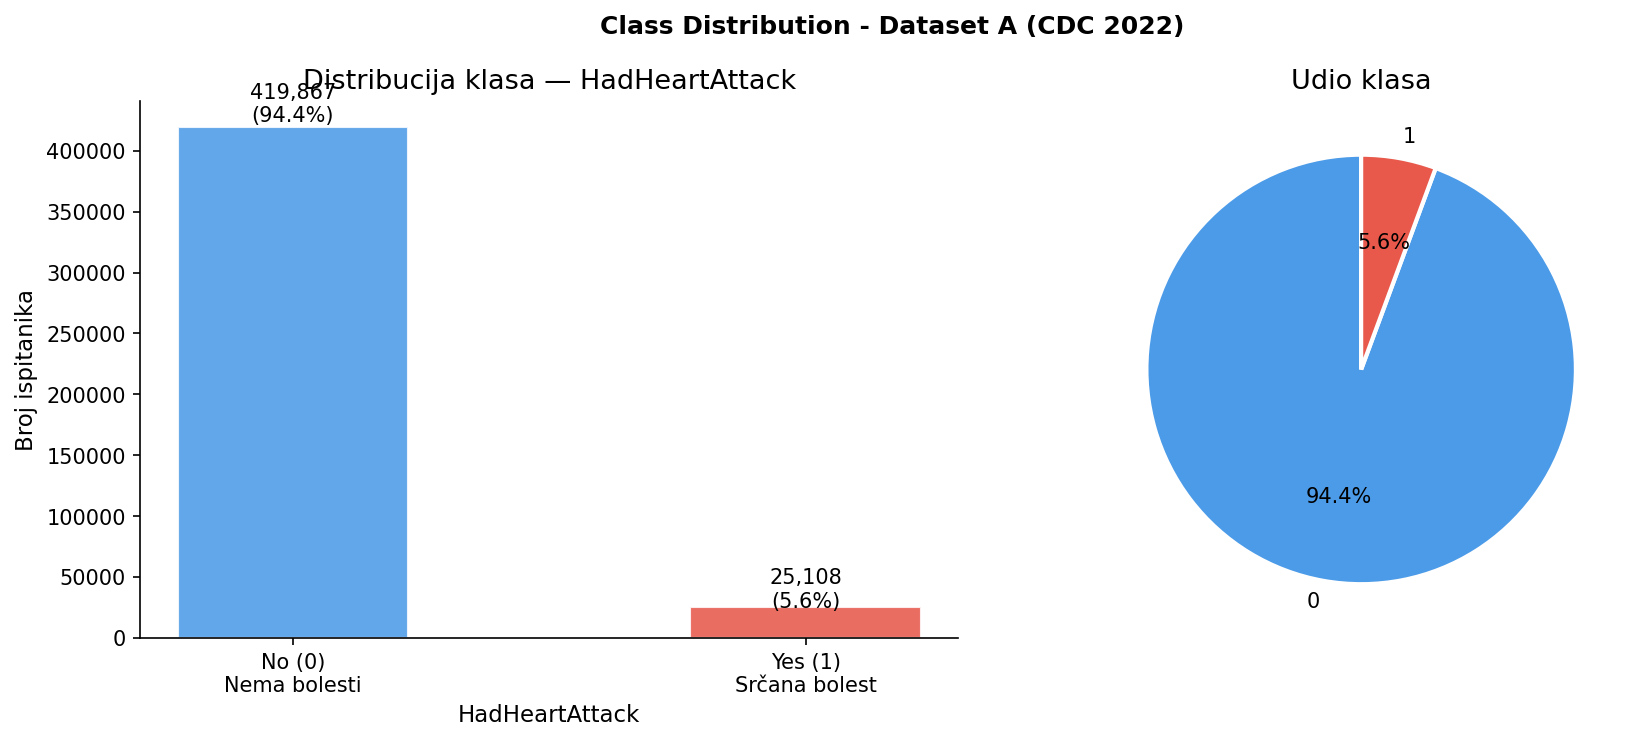

In [9]:
# Target kolona
TARGET_A = 'HadHeartAttack' 

if TARGET_A not in df_a.columns:
    print('UPOZORENJE: Target kolona nije pronađena!')
    print('Dostupne kolone:')
    for i, c in enumerate(df_a.columns):
        print(f'{i:2d}. {c}')
    raise ValueError(f'Promijenite TARGET_A na ispravno ime kolone.')

if df_a[TARGET_A].dtype == object:
    print(f'Vrijednosti u targetu: {df_a[TARGET_A].unique()}')
    df_a[TARGET_A] = df_a[TARGET_A].map({'Yes': 1, 'No': 0})
    print('Konvertovano: Yes1->, No->0')

counts_a = df_a[TARGET_A].value_counts().sort_index()
ratio_a = counts_a.max() / counts_a.min()

print(f'Target: {TARGET_A}')
print(f'Distribucija klasa:')
for k, v in counts_a.items():
    lbl = 'Nema srčane bolesti' if k == 0 else 'Srčana bolest'
    print(f'{k} ({lbl}): {v:,} ({v/len(df_a)*100:.1f}%)')
print(f'Omjer klasa: {ratio_a:.1f}:1')
if ratio_a > 3:
    print('Class imbalance detektovan. Primijenit ćemo SMOTE.')
else:
    print('Klase su relativno uravnotežene.')

# Vizualizacija
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bar_labels = ['No (0)\nNema bolesti', 'Yes (1)\nSrčana bolest']
colors = [PALETTE['negative'], PALETTE['positive']]

axes[0].bar(bar_labels[:len(counts_a)], counts_a.values,
            color=colors[:len(counts_a)], edgecolor='white', alpha=0.88, width=0.45)
axes[0].set_title(f'Distribucija klasa — {TARGET_A}')
axes[0].set_xlabel(TARGET_A)
axes[0].set_ylabel('Broj ispitanika')
for i, v in enumerate(counts_a.values):
    axes[0].text(i, v * 1.01, f'{v:,}\n({v/len(df_a)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(counts_a.values, labels=counts_a.index.astype(str), autopct='%1.1f%%',
            colors=colors[:len(counts_a)], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Udio klasa')

plt.suptitle('Class Distribution - Dataset A (CDC 2022)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/A_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 EDA — Distribucije numeričkih varijabli

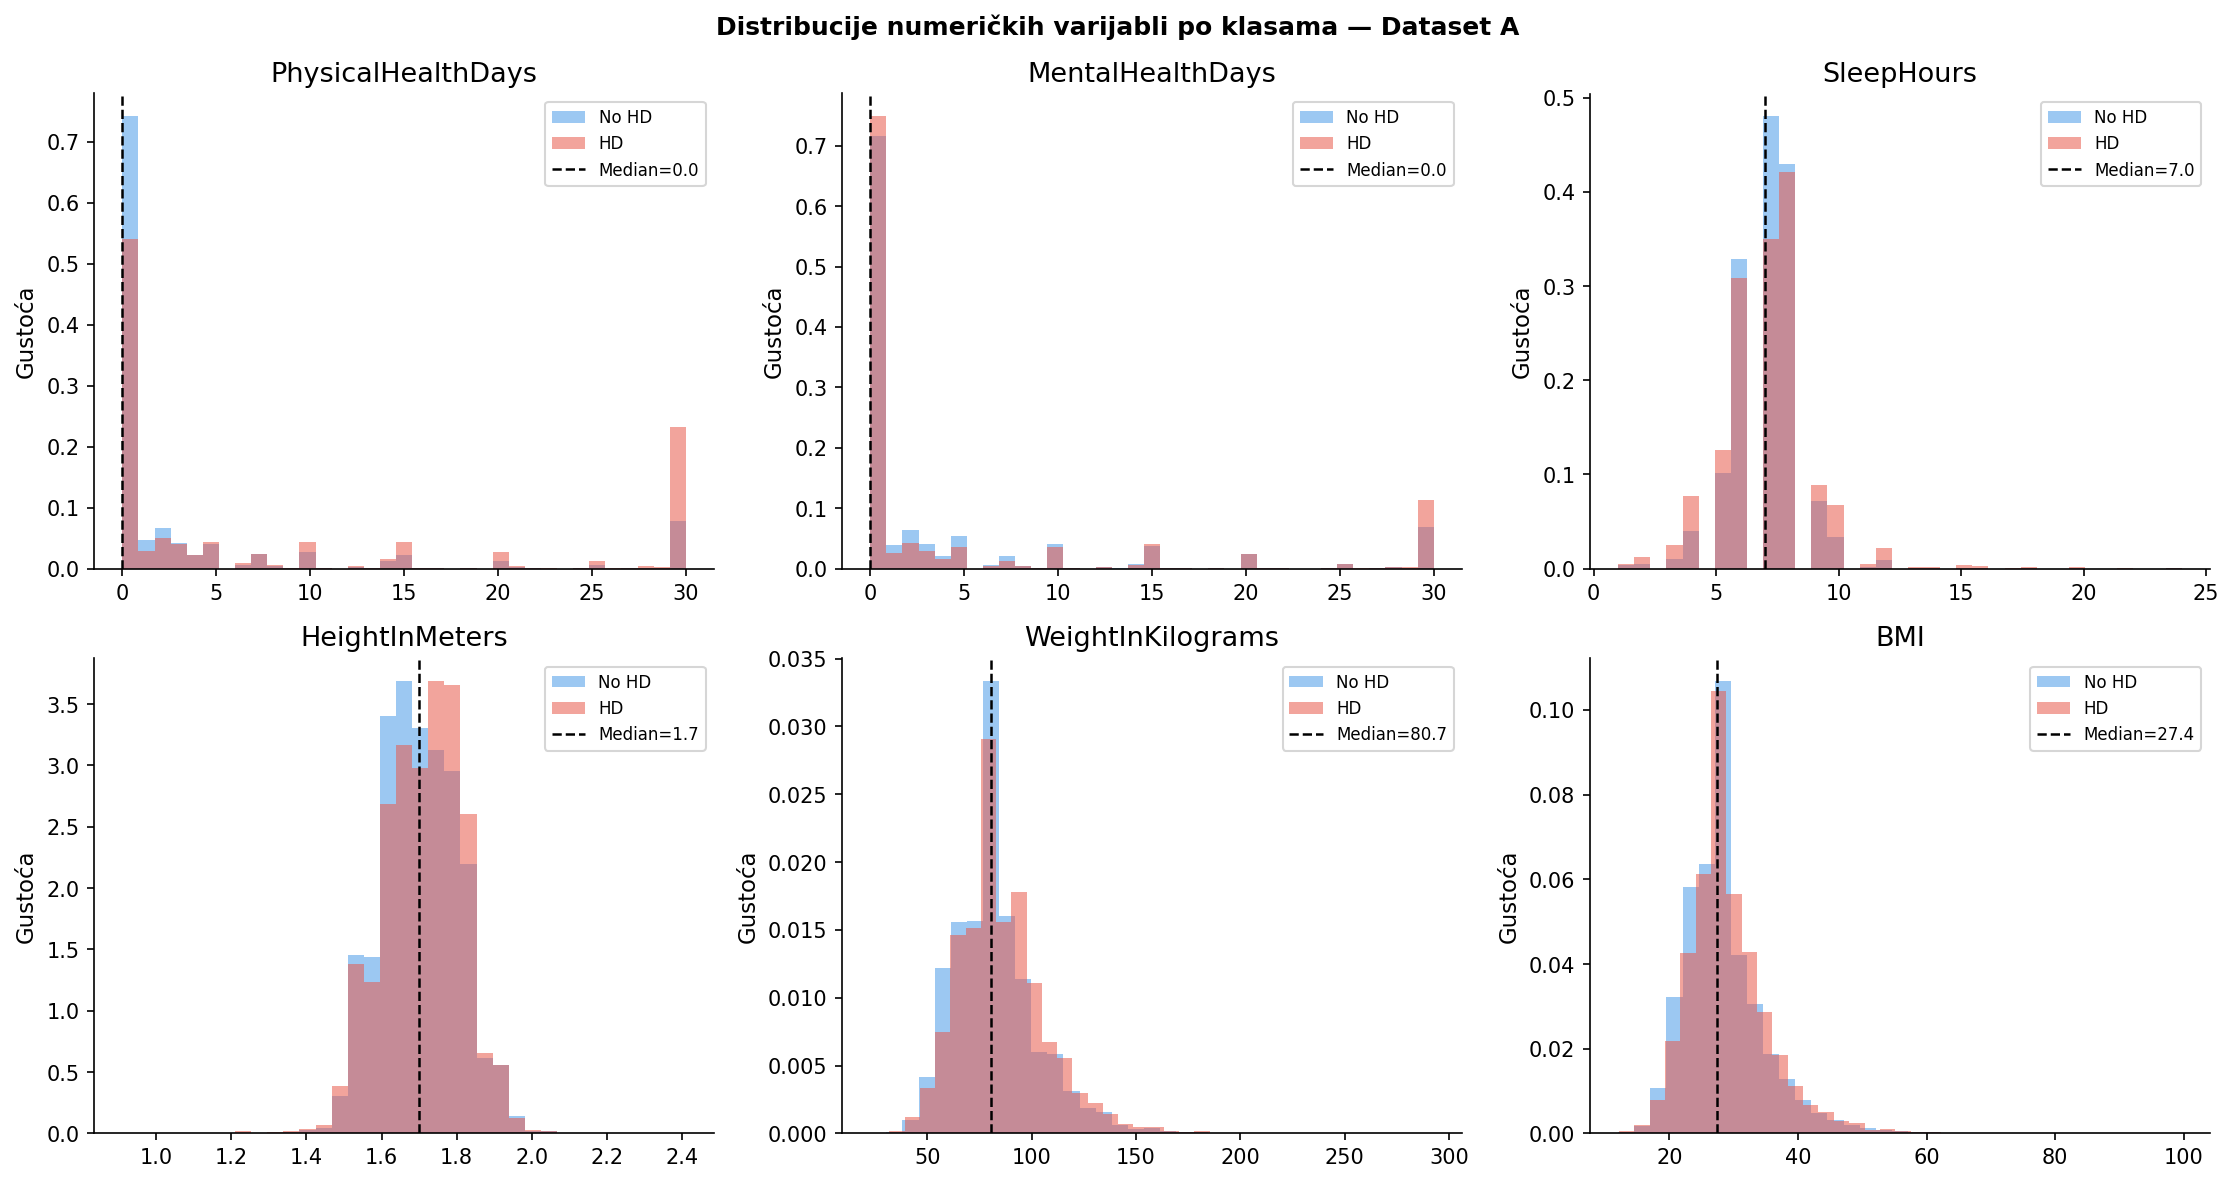

In [10]:
num_cols_a = [c for c in df_a.select_dtypes(include='number').columns if c != TARGET_A]

if len(num_cols_a) > 0:
    n_cols = 3
    n_rows = (len(num_cols_a) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(num_cols_a):
        for cls, clr, lbl in [(0, PALETTE['negative'], 'No HD'), (1, PALETTE['positive'], 'HD')]:
            sub = df_a[df_a[TARGET_A] == cls][col].dropna()
            axes[i].hist(sub, bins=35, color=clr, alpha=0.55,
                         edgecolor='none', label=lbl, density=True)
        med = df_a[col].median()
        axes[i].axvline(med, color='black', linestyle='--', lw=1.2, label=f'Median={med:.1f}')
        axes[i].set_title(col)
        axes[i].set_ylabel('Gustoća')
        axes[i].legend(fontsize=8)

    for j in range(len(num_cols_a), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribucije numeričkih varijabli po klasama — Dataset A', fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/A_numeric_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Nema numeričkih kolona za prikaz.')

### 2.5 EDA — Kategoričke varijable vs Target

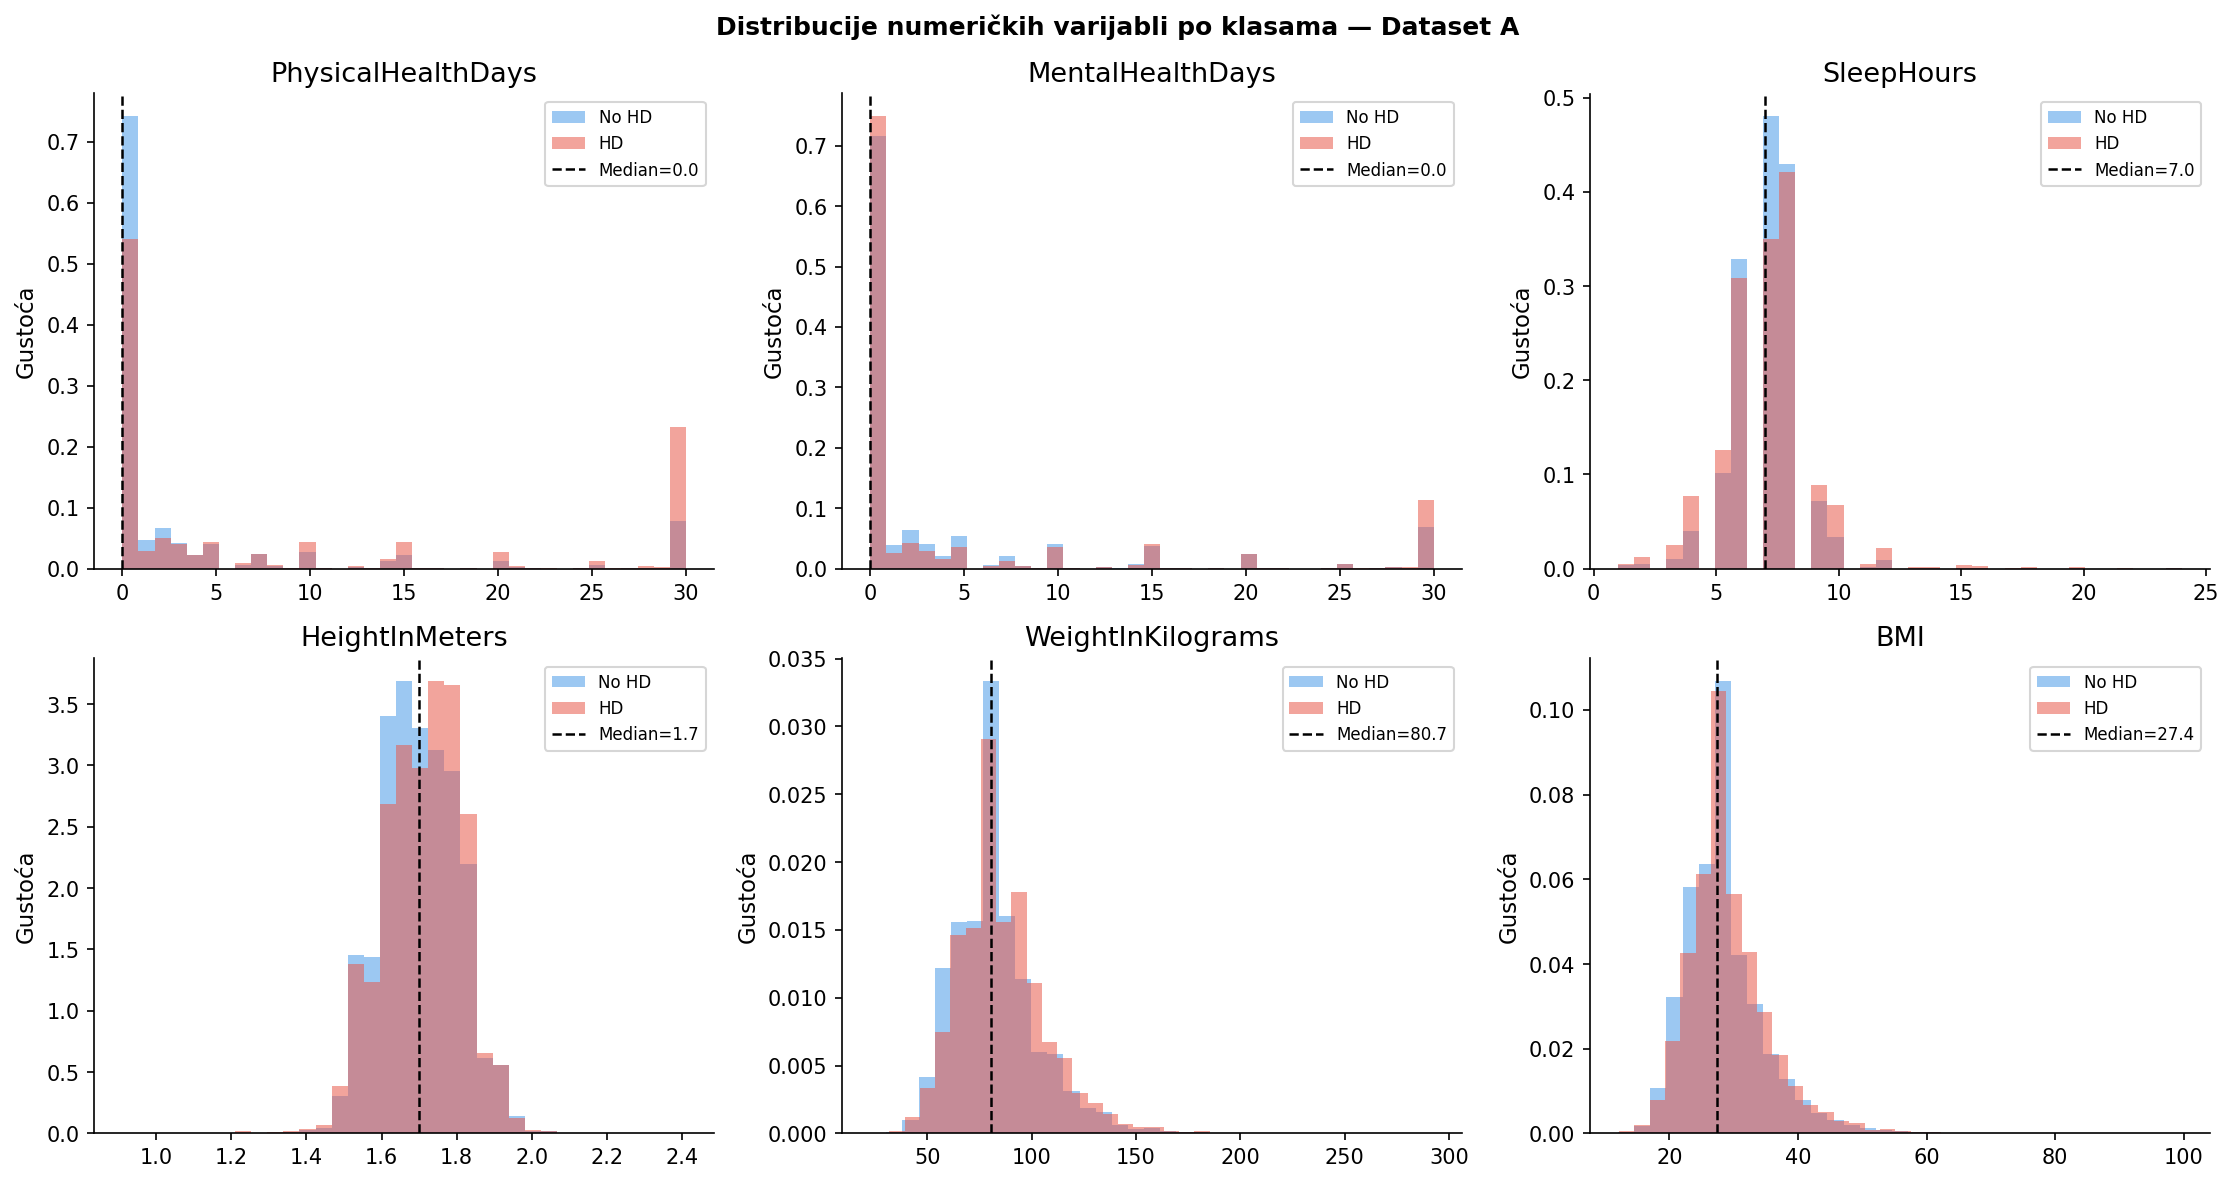

In [11]:
num_cols_a = [c for c in df_a.select_dtypes(include='number').columns if c != TARGET_A]

if len(num_cols_a) > 0:
    n_cols = 3
    n_rows = (len(num_cols_a) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(num_cols_a):
        for cls, clr, lbl in [(0, PALETTE['negative'], 'No HD'), (1, PALETTE['positive'], 'HD')]:
            sub = df_a[df_a[TARGET_A] == cls][col].dropna()
            axes[i].hist(sub, bins=35, color=clr, alpha=0.55,
                         edgecolor='none', label=lbl, density=True)
        med = df_a[col].median()
        axes[i].axvline(med, color='black', linestyle='--', lw=1.2, label=f'Median={med:.1f}')
        axes[i].set_title(col)
        axes[i].set_ylabel('Gustoća')
        axes[i].legend(fontsize=8)

    for j in range(len(num_cols_a), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribucije numeričkih varijabli po klasama — Dataset A', fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/A_numeric_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Nema numeričkih kolona za prikaz.')

### 2.6 EDA — Korelacijska matrica

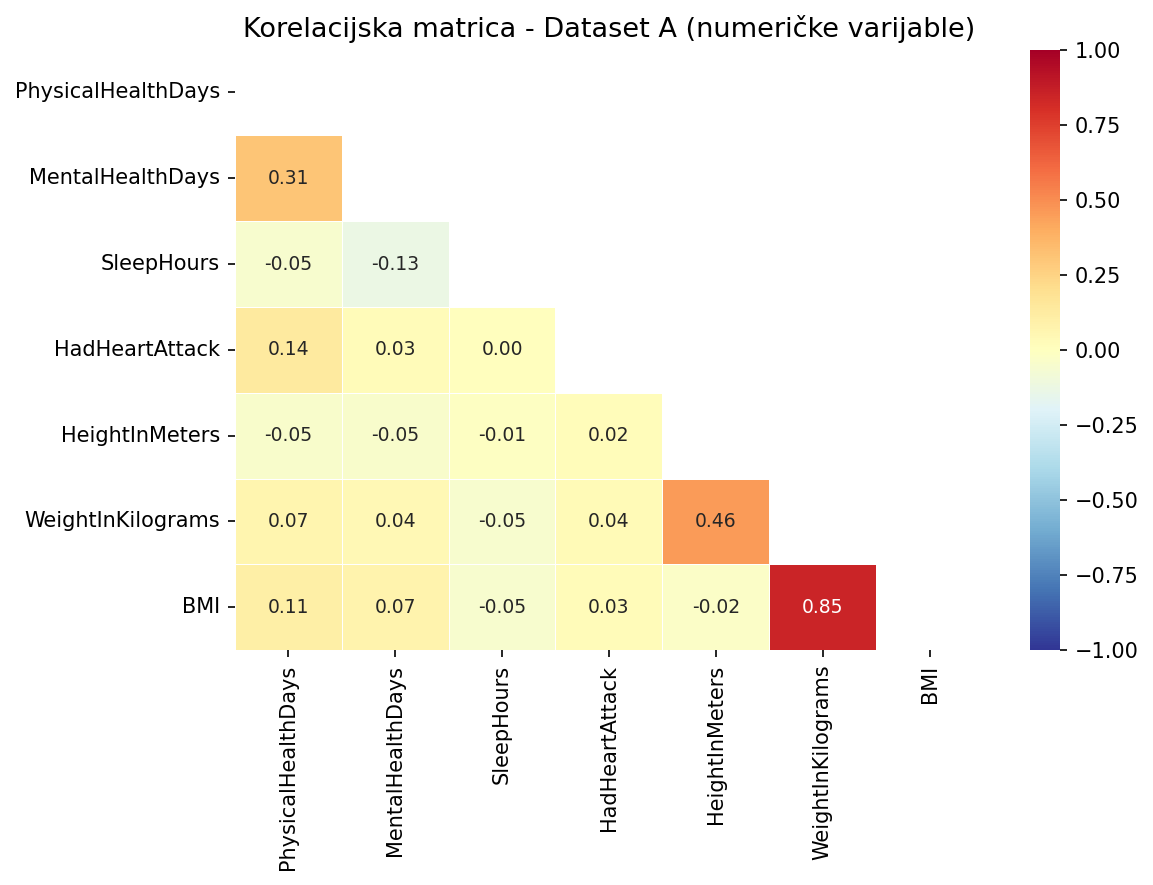


Top korelacije s targetom (HadHeartAttack):
PhysicalHealthDays    0.136109
WeightInKilograms     0.036447
BMI                   0.029799
MentalHealthDays      0.027850
HeightInMeters        0.021105
SleepHours            0.003808


In [12]:
# Korelacija samo na numeričkim kolonama (uključujući target ako je numerički)
all_num_a = df_a.select_dtypes(include='number').columns.tolist()

if len(all_num_a) > 1:
    corr_a = df_a[all_num_a].corr()
    mask = np.triu(np.ones_like(corr_a, dtype=bool))  

    fig, ax = plt.subplots(figsize=(max(8, len(all_num_a)), max(6, len(all_num_a) - 1)))
    sns.heatmap(corr_a, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
                mask=mask, ax=ax, linewidths=0.4, annot_kws={'size': 9},
                vmin=-1, vmax=1)
    ax.set_title('Korelacijska matrica - Dataset A (numeričke varijable)')
    plt.tight_layout()
    plt.savefig('figures/A_correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Top korelacije s targetom (ako je numerički)
    if TARGET_A in all_num_a:
        top_corr = corr_a[TARGET_A].drop(TARGET_A).abs().sort_values(ascending=False)
        print(f'\nTop korelacije s targetom ({TARGET_A}):')
        print(top_corr.head(10).to_string())

### 2.7 Preprocessing — Enkodiranje, Skaliranje, Train/Test Split, SMOTE
> Scaler i SMOTE se fituju **isključivo na trening skupu**. Primjenjuju se na test skup bez ponovnog fitovanja. Ovo sprečava data leakage.

In [13]:
df_a_proc = df_a.copy()

# ENKODIRANJE KATEGORIČKIH VARIJABLI 
cat_cols_to_enc_a = df_a_proc.select_dtypes(include='object').columns.tolist()
oe_a = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_a_proc[cat_cols_to_enc_a] = oe_a.fit_transform(df_a_proc[cat_cols_to_enc_a])

print('Enkodirane kategoričke kolone:')
for col, cats in zip(cat_cols_to_enc_a, oe_a.categories_):
    print(f'{col}: {list(cats)[:5]}...' if len(cats) > 5 else f'  {col}: {list(cats)}')

# FEATURES I TARGET 
feature_cols_a = [c for c in df_a_proc.columns if c != TARGET_A]
X_a = df_a_proc[feature_cols_a].values
y_a = df_a_proc[TARGET_A].values

print(f'\nX shape: {X_a.shape}')
print(f'y shape: {y_a.shape}')
print(f'Klase: {np.unique(y_a)}')

Enkodirane kategoričke kolone:
State: ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California']...
  Sex: ['Female', 'Male']
  GeneralHealth: ['Excellent', 'Fair', 'Good', 'Poor', 'Very good']
  LastCheckupTime: ['5 or more years ago', 'Within past 2 years (1 year but less than 2 years ago)', 'Within past 5 years (2 years but less than 5 years ago)', 'Within past year (anytime less than 12 months ago)']
  PhysicalActivities: ['No', 'Yes']
  RemovedTeeth: ['1 to 5', '6 or more, but not all', 'All', 'None of them']
  HadAngina: ['No', 'Yes']
  HadStroke: ['No', 'Yes']
  HadAsthma: ['No', 'Yes']
  HadSkinCancer: ['No', 'Yes']
  HadCOPD: ['No', 'Yes']
  HadDepressiveDisorder: ['No', 'Yes']
  HadKidneyDisease: ['No', 'Yes']
  HadArthritis: ['No', 'Yes']
  HadDiabetes: ['No', 'No, pre-diabetes or borderline diabetes', 'Yes', 'Yes, but only during pregnancy (female)']
  DeafOrHardOfHearing: ['No', 'Yes']
  BlindOrVisionDifficulty: ['No', 'Yes']
  DifficultyConcentrating: ['No', 'Yes']
  Diff

In [14]:
# TRAIN / TEST SPLIT (80/20) 
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a, y_a,
    test_size=0.20,
    random_state=SEED,
    stratify=y_a  
)

print(f'Train: {X_a_train.shape[0]:,} uzoraka')
print(f'Test: {X_a_test.shape[0]:,} uzoraka')

# Provjera distribucije klasa u train i test skupu
for name, y_split in [('Train', y_a_train), ('Test', y_a_test)]:
    unique, counts = np.unique(y_split, return_counts=True)
    print(f'{name}: {dict(zip(unique, counts))}')

Train: 355,980 uzoraka
Test: 88,995 uzoraka
Train: {np.int64(0): np.int64(335894), np.int64(1): np.int64(20086)}
Test: {np.int64(0): np.int64(83973), np.int64(1): np.int64(5022)}


In [15]:
# SKALIRANJE (fit SAMO na train) 
scaler_a = StandardScaler()
X_a_train_sc = scaler_a.fit_transform(X_a_train)   
X_a_test_sc = scaler_a.transform(X_a_test)        

print('Skaliranje završeno.')
print(f'Train mean (prva kolona): {X_a_train_sc[:, 0].mean():.4f} (očekivano ≈ 0)')
print(f'Train std (prva kolona): {X_a_train_sc[:, 0].std():.4f} (očekivano ≈ 1)')
print(f'Test mean (prva kolona): {X_a_test_sc[:, 0].mean():.4f} (može biti ≠ 0 - to je OK)')

Skaliranje završeno.
Train mean (prva kolona): 0.0000 (očekivano ≈ 0)
Train std (prva kolona): 1.0000 (očekivano ≈ 1)
Test mean (prva kolona): -0.0044 (može biti ≠ 0 - to je OK)


In [16]:
# SMOTE — balansiranje klasa 
# Primjenjujemo SAMO na train skup!

counts_before = dict(zip(*np.unique(y_a_train, return_counts=True)))
ratio_before = max(counts_before.values()) / min(counts_before.values())
print(f'Distribucija PRIJE SMOTE: {counts_before} (omjer {ratio_before:.1f}:1)')

if ratio_before > 1.5:  # primijeni SMOTE samo ako postoji stvarni imbalance
    smote = SMOTE(random_state=SEED)
    X_a_train_res, y_a_train_res = smote.fit_resample(X_a_train_sc, y_a_train)
    counts_after = dict(zip(*np.unique(y_a_train_res, return_counts=True)))
    print(f'Distribucija NAKON SMOTE: {counts_after}')
    print(f'Train skup povećan na: {len(y_a_train_res):,} uzoraka')
    SMOTE_APPLIED_A = True
else:
    X_a_train_res, y_a_train_res = X_a_train_sc, y_a_train
    print('Klase su dovoljno uravnotežene - SMOTE nije primijenjen.')
    SMOTE_APPLIED_A = False

print(f'\nDataset A spreman za modeliranje:')
print(f'X_a_train_res: {X_a_train_res.shape}')
print(f'X_a_test_sc: {X_a_test_sc.shape}')
print(f'Feature names: {feature_cols_a}')

Distribucija PRIJE SMOTE: {np.int64(0): np.int64(335894), np.int64(1): np.int64(20086)} (omjer 16.7:1)
Distribucija NAKON SMOTE: {np.int64(0): np.int64(335894), np.int64(1): np.int64(335894)}
Train skup povećan na: 671,788 uzoraka

Dataset A spreman za modeliranje:
X_a_train_res: (671788, 39)
X_a_test_sc: (88995, 39)
Feature names: ['State', 'Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRi

## 3. Dataset B - Heart Failure Prediction (klinički)

### 3.1 Provjera kvaliteta podataka

In [17]:
quality_report(df_b_raw, 'Dataset B - Heart Failure')


 QUALITY REPORT — Dataset B - Heart Failure
Dimenzije: 918 redova × 12 kolona
Duplikati: 0
Ukupno missing values: 0
Nema missing values.

 Numeričke kolone (7): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
Kategoričke kolone (5): ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


### 3.2 Čišćenje

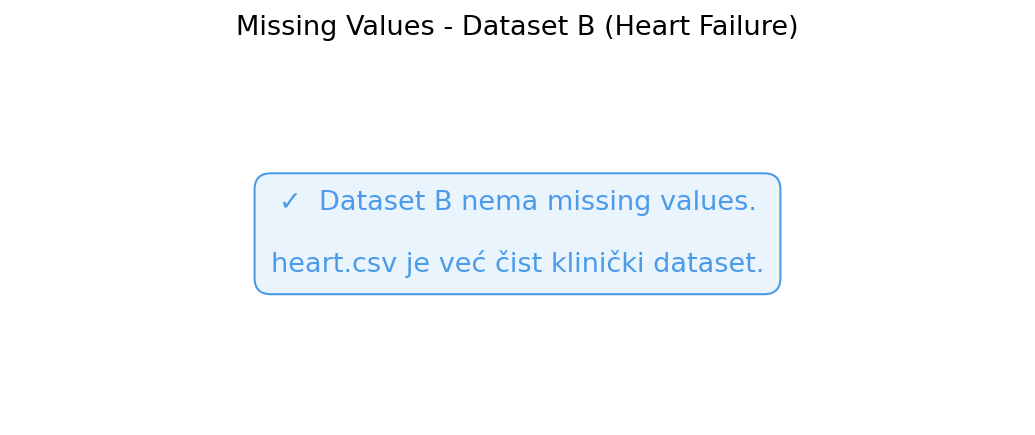

Dataset B nema missing values.


In [18]:
# Vizualizacija missing values - Dataset B
mv_b = df_b_raw.isnull().sum()
mv_b = mv_b[mv_b > 0].sort_values(ascending=False)

if len(mv_b) > 0:
    fig, ax = plt.subplots(figsize=(11, max(4, len(mv_b) * 0.55)))
    pcts_b = mv_b.values / len(df_b_raw) * 100
    bars = ax.barh(mv_b.index, pcts_b, color='#4C9BE8', alpha=0.82, edgecolor='white')
    for bar, val, pct in zip(bars, mv_b.values, pcts_b):
        ax.text(pct + 0.15, bar.get_y() + bar.get_height() / 2,
                f'{val} ({pct:.1f}%)', va='center', fontsize=9)
    ax.set_xlabel('Missing values (%)')
    ax.set_title('Missing Values po koloni — Dataset B (Heart Failure)', fontsize=13)
    ax.set_xlim(0, pcts_b.max() * 1.35)
    plt.tight_layout()
    plt.savefig('figures/B_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.text(0.5, 0.5, '✓  Dataset B nema missing values.\n\nheart.csv je već čist klinički dataset.',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=13, color='#4C9BE8',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#EAF4FD', edgecolor='#4C9BE8'))
    ax.axis('off')
    ax.set_title('Missing Values - Dataset B (Heart Failure)', fontsize=13)
    plt.tight_layout()
    plt.savefig('figures/B_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Dataset B nema missing values.')

In [19]:
df_b = df_b_raw.copy()

# Uklanjanje duplikata
n_before = len(df_b)
df_b = df_b.drop_duplicates()
print(f'Duplikati uklonjeni: {n_before - len(df_b)}')

# Popunjavanje missing values
for col in df_b.select_dtypes(include='number').columns:
    n_missing = df_b[col].isnull().sum()
    if n_missing > 0:
        med = df_b[col].median()
        df_b[col] = df_b[col].fillna(med)
        print(f'[NUM] {col}: {n_missing} → median={med:.2f}')

for col in df_b.select_dtypes(include='object').columns:
    n_missing = df_b[col].isnull().sum()
    if n_missing > 0:
        mod = df_b[col].mode()[0]
        df_b[col] = df_b[col].fillna(mod)
        print(f'[CAT] {col}: {n_missing} → modus="{mod}"')

print(f'Missing values preostalo: {df_b.isnull().sum().sum()}')
print(f'Finalni Dataset B: {df_b.shape}')

Duplikati uklonjeni: 0
Missing values preostalo: 0
Finalni Dataset B: (918, 12)


### 3.3 EDA — Dataset B

In [20]:
TARGET_B = 'HeartDisease'

if TARGET_B not in df_b.columns:
    print('Dostupne kolone:', list(df_b.columns))
    raise ValueError('Promijenite TARGET_B!')

counts_b = df_b[TARGET_B].value_counts().sort_index()
ratio_b = counts_b.max() / counts_b.min()

print(f'Target: {TARGET_B}')
for k, v in counts_b.items():
    print(f'Klasa {k}: {v} ({v/len(df_b)*100:.1f}%)')
print(f'Omjer: {ratio_b:.2f}:1')

Target: HeartDisease
Klasa 0: 410 (44.7%)
Klasa 1: 508 (55.3%)
Omjer: 1.24:1


In [21]:
# CLASS DISTRIBUTION 
bar_labels_b = ['No HD (0)\nNema bolesti', 'HD (1)\nSrčana bolest']
colors_b = [PALETTE['negative'], PALETTE['positive']]

axes[0].bar(bar_labels_b[:len(counts_b)], counts_b.values,
            color=colors_b[:len(counts_b)], edgecolor='white', alpha=0.88, width=0.45)
axes[0].set_title(f'Distribucija klasa — {TARGET_B}')
axes[0].set_ylabel('Broj pacijenata')
for i, v in enumerate(counts_b.values):
    axes[0].text(i, v * 1.01, f'{v}\n({v/len(df_b)*100:.1f}%)', ha='center', fontsize=11)

axes[1].pie(counts_b.values, labels=bar_labels_b[:len(counts_b)],
            autopct='%1.1f%%', colors=colors_b[:len(counts_b)],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Udio klasa')

plt.suptitle('Class Distribution - Dataset B (Heart Failure)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/B_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 960x720 with 0 Axes>

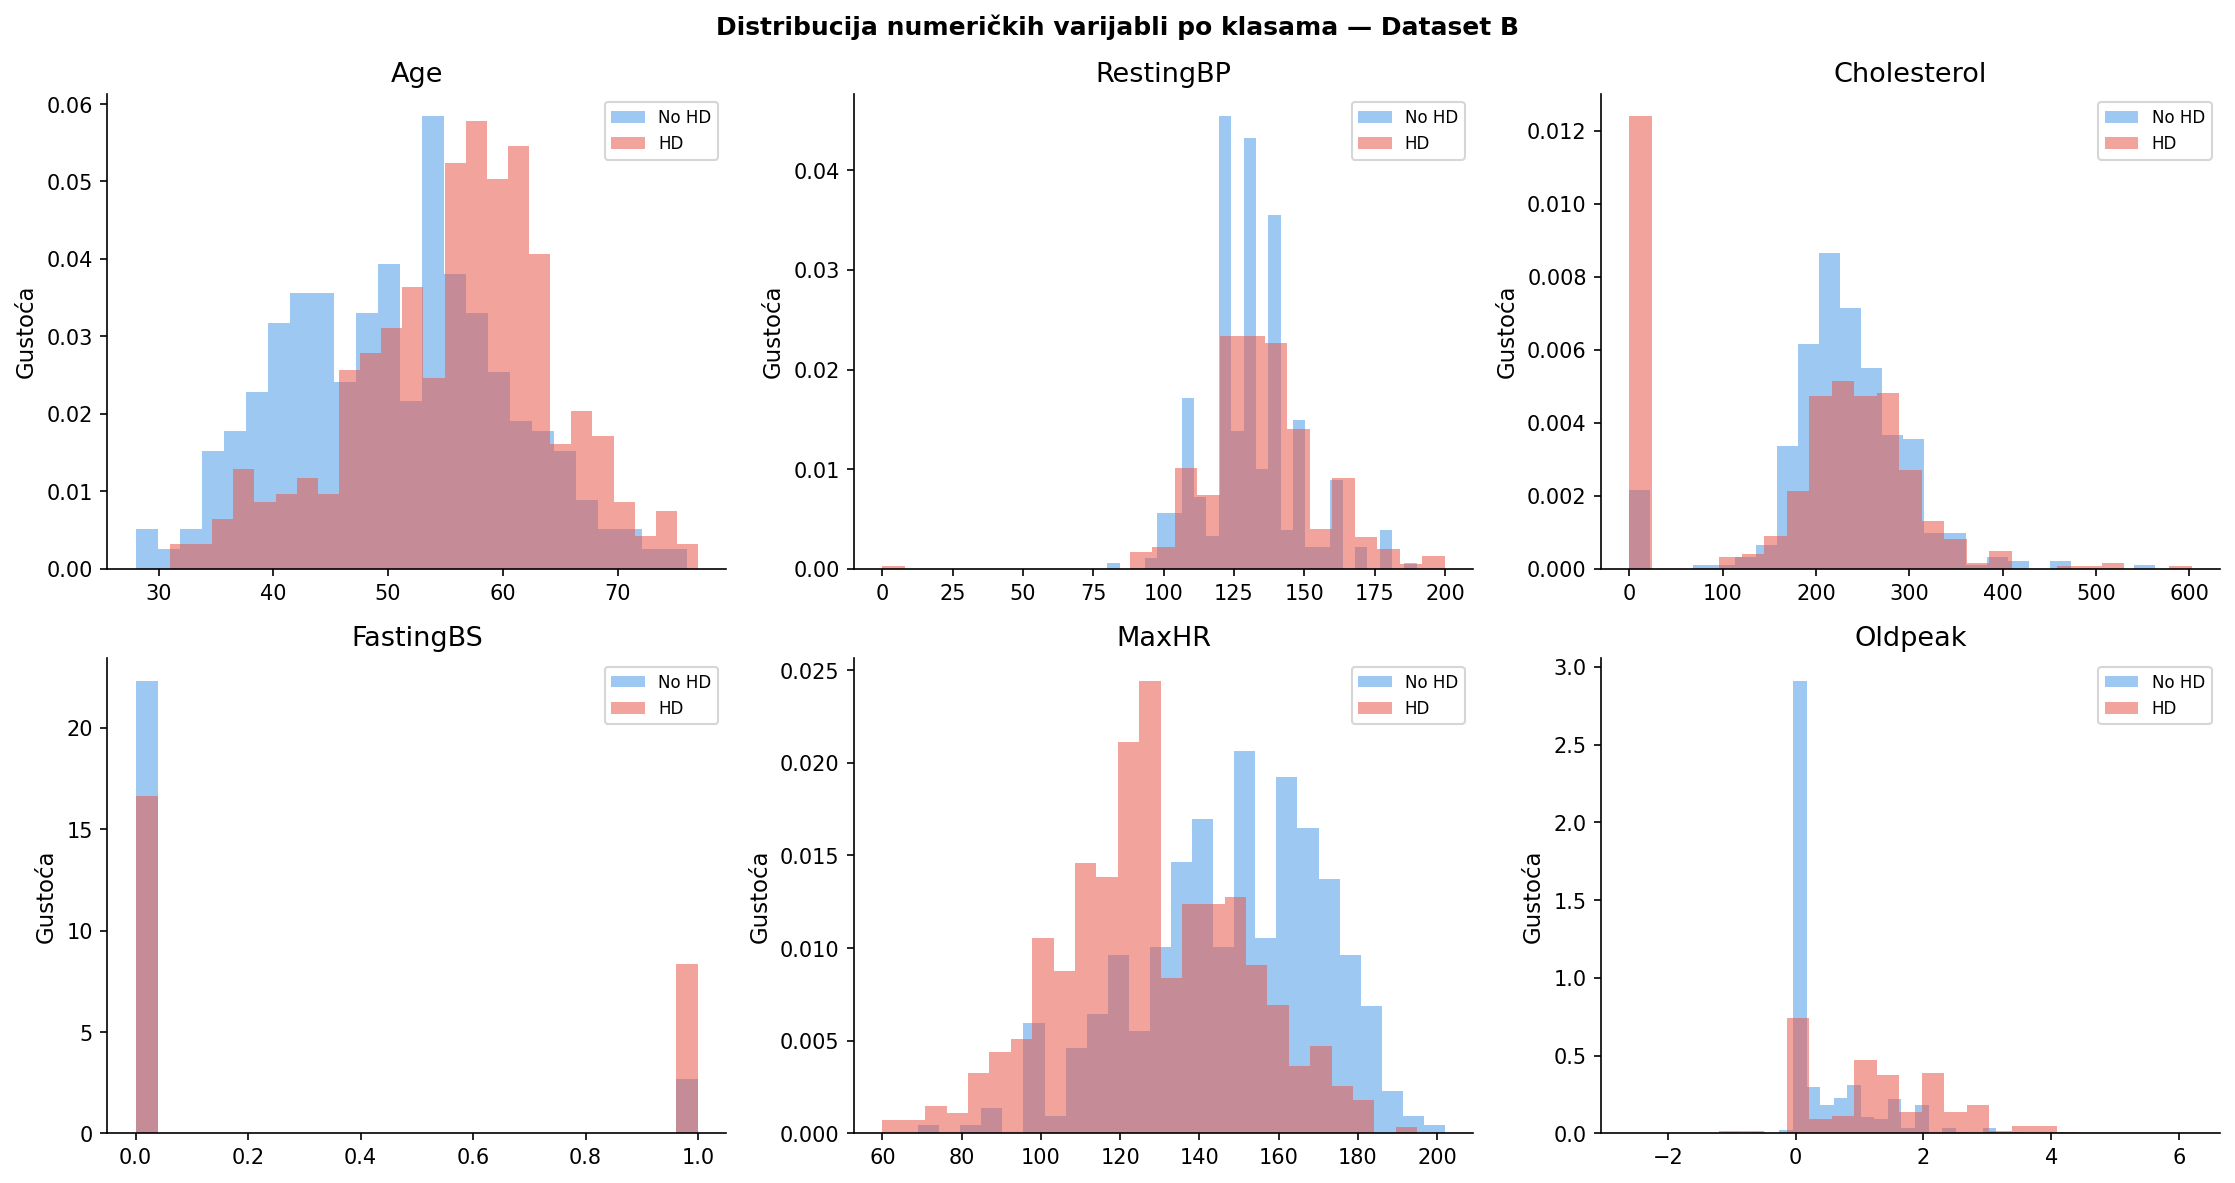

In [22]:
# HISTOGRAMI po klasi
num_cols_b = [c for c in df_b.select_dtypes(include='number').columns if c != TARGET_B]
n_cols = 3
n_rows = (len(num_cols_b) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols_b):
    for cls, clr, lbl in [(0, PALETTE['negative'], 'No HD'), (1, PALETTE['positive'], 'HD')]:
        sub = df_b[df_b[TARGET_B] == cls][col].dropna()
        axes[i].hist(sub, bins=25, color=clr, alpha=0.55, edgecolor='none', label=lbl, density=True)
    axes[i].set_title(col)
    axes[i].set_ylabel('Gustoća')
    axes[i].legend(fontsize=8)

for j in range(len(num_cols_b), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucija numeričkih varijabli po klasama — Dataset B', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/B_numeric_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

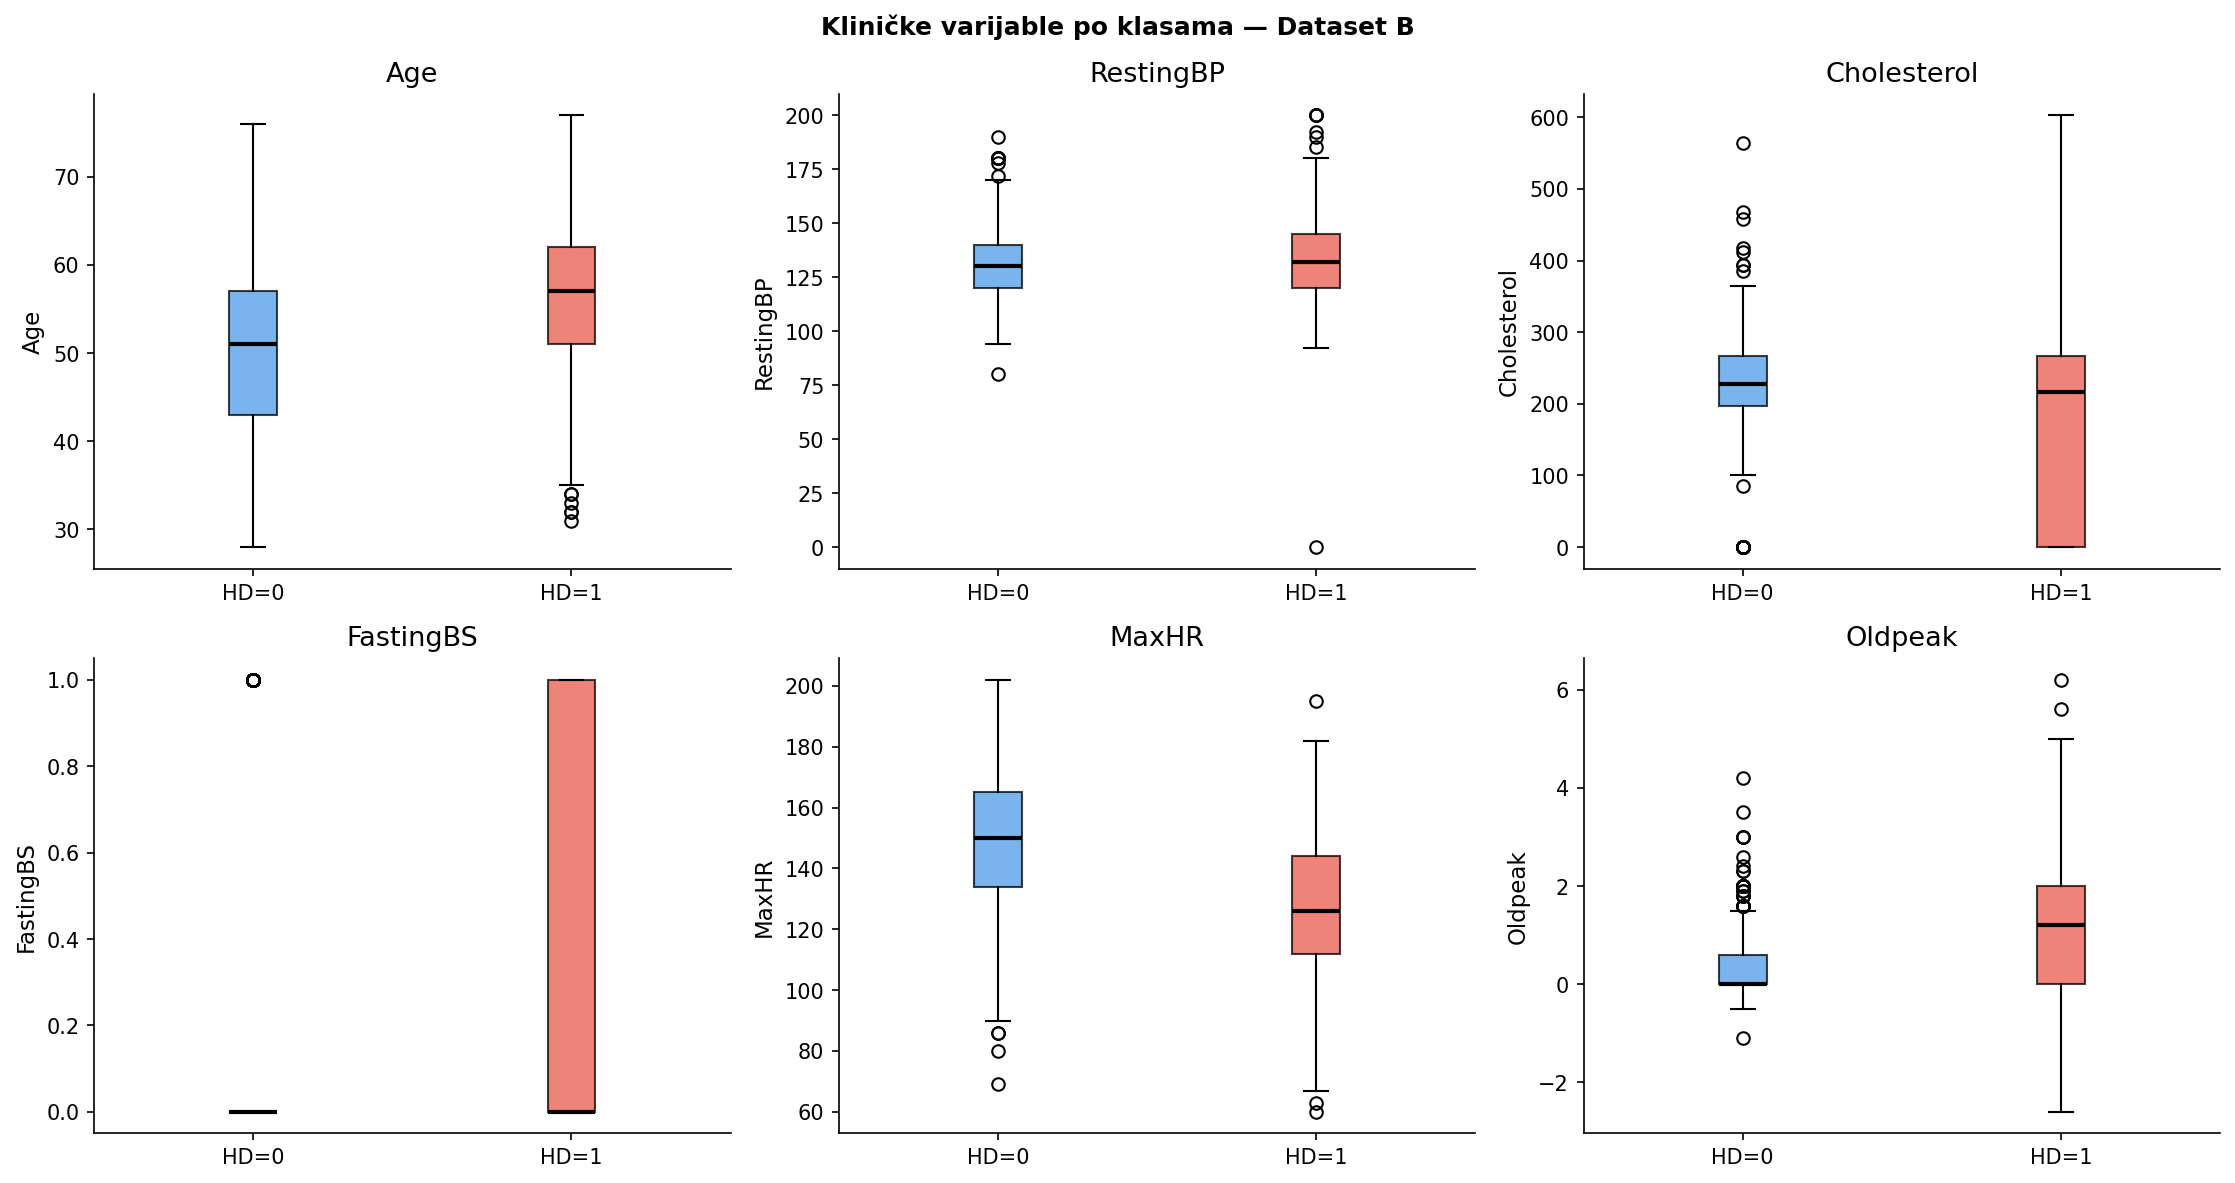

In [23]:
# BOXPLOTI
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols_b):
    groups = [df_b[df_b[TARGET_B] == v][col].dropna()
              for v in sorted(df_b[TARGET_B].unique())]
    labels = [f'HD={v}' for v in sorted(df_b[TARGET_B].unique())]
    bp = axes[i].boxplot(groups, patch_artist=True, labels=labels,
                          medianprops={'color': 'black', 'linewidth': 2})
    for patch, c in zip(bp['boxes'], [PALETTE['negative'], PALETTE['positive']]):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

for j in range(len(num_cols_b), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Kliničke varijable po klasama — Dataset B', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/B_boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

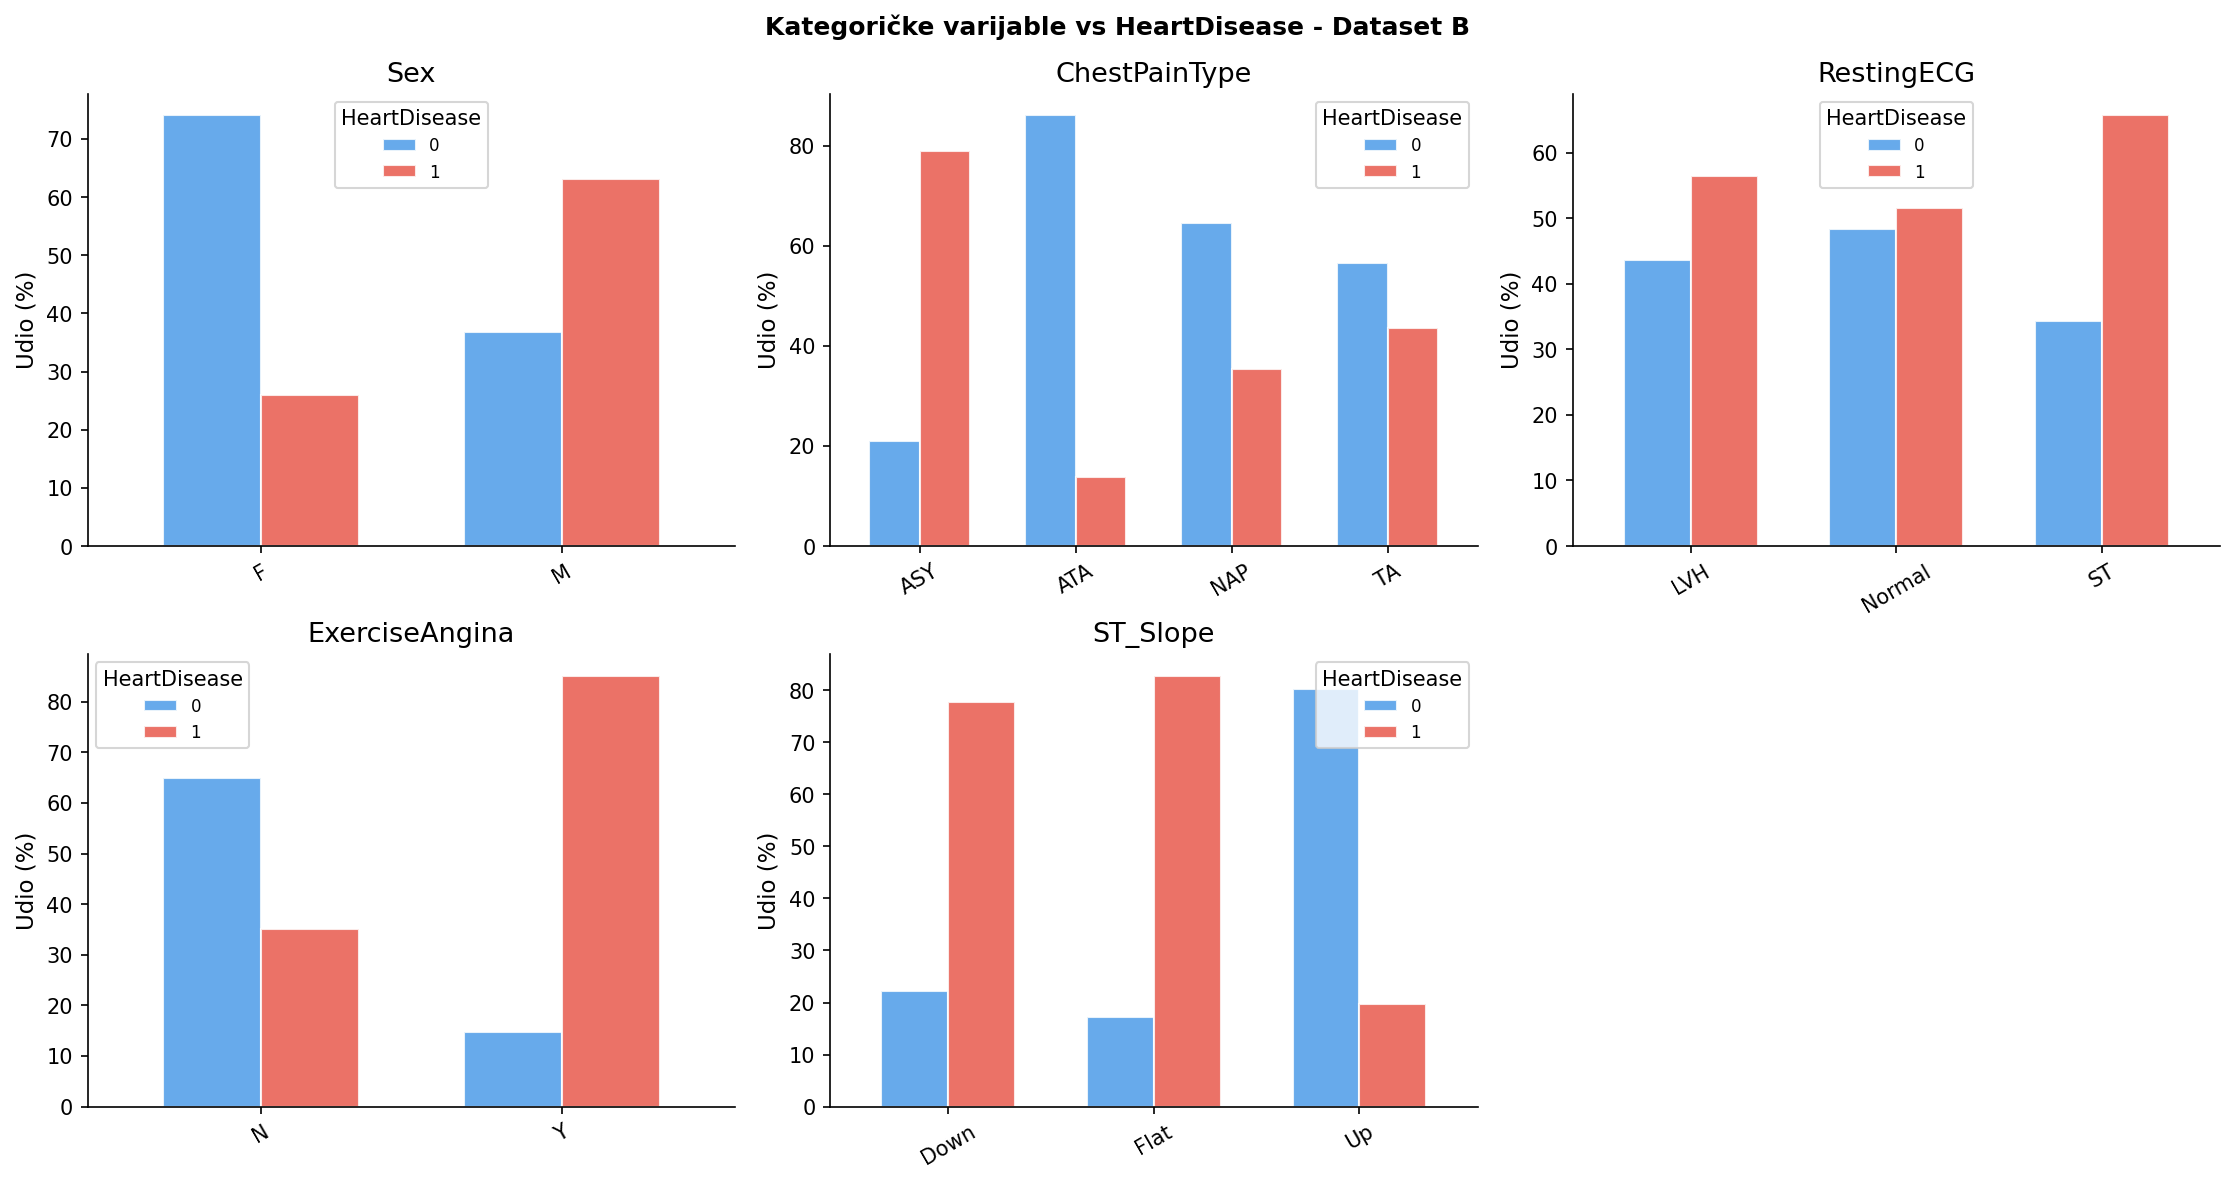

In [24]:
# KATEGORIČKE vs TARGET 
cat_cols_b_vis = [c for c in df_b.select_dtypes(include='object').columns if c != TARGET_B]
if cat_cols_b_vis:
    n_c = min(3, len(cat_cols_b_vis))
    n_r = (len(cat_cols_b_vis) + n_c - 1) // n_c
    fig, axes = plt.subplots(n_r, n_c, figsize=(15, n_r * 4))
    axes = np.array(axes).flatten()
    for i, col in enumerate(cat_cols_b_vis):
        ct = pd.crosstab(df_b[col], df_b[TARGET_B], normalize='index') * 100
        ct.sort_index(axis=1).plot(kind='bar', ax=axes[i],
            color=[PALETTE['negative'], PALETTE['positive']][:len(ct.columns)],
            edgecolor='white', alpha=0.85, width=0.65)
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Udio (%)')
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].legend(title=TARGET_B, fontsize=8)
    for j in range(len(cat_cols_b_vis), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Kategoričke varijable vs HeartDisease - Dataset B', fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/B_categorical_vs_target.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Dataset B nema kategoričkih varijabli (sve su numeričke).')

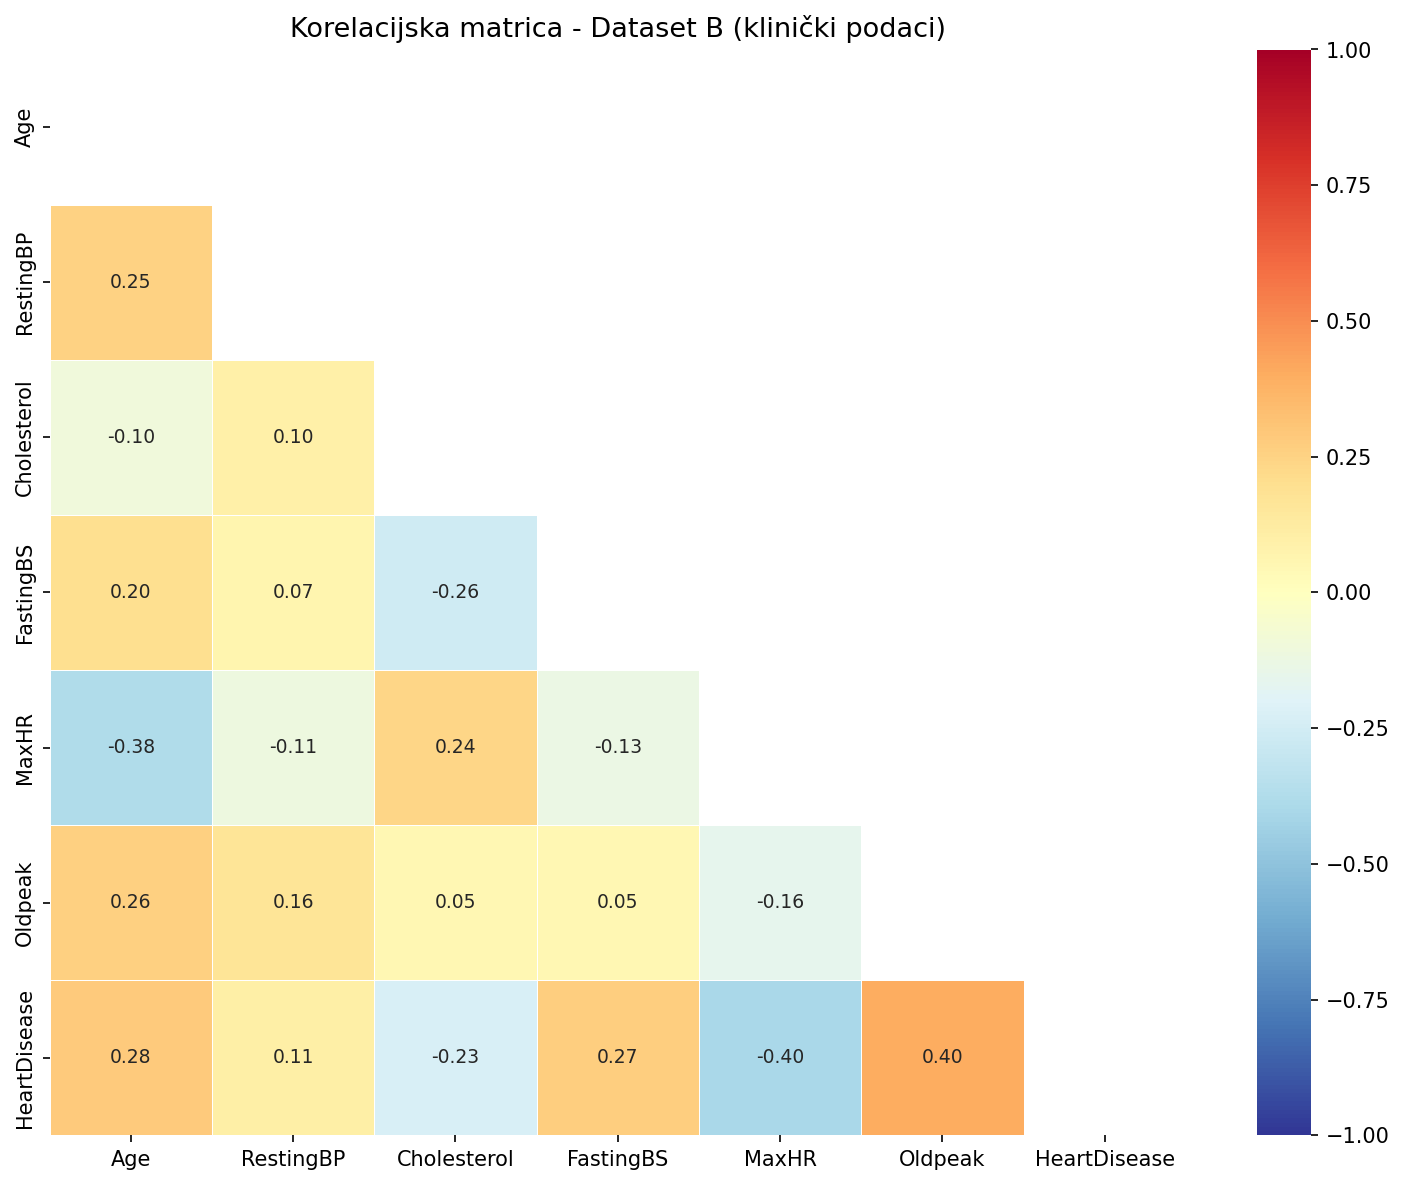

Top korelacije s HeartDisease:
Oldpeak        0.403951
MaxHR          0.400421
Age            0.282039
FastingBS      0.267291
Cholesterol    0.232741
RestingBP      0.107589


In [25]:
# Korelacijska matrica - Dataset B
all_num_b = df_b.select_dtypes(include='number').columns.tolist()
corr_b = df_b[all_num_b].corr()
mask_b = np.triu(np.ones_like(corr_b, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_b, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            mask=mask_b, ax=ax, linewidths=0.4, annot_kws={'size': 9},
            vmin=-1, vmax=1)
ax.set_title('Korelacijska matrica - Dataset B (klinički podaci)')
plt.tight_layout()
plt.savefig('figures/B_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Top korelacije s targetom
if TARGET_B in all_num_b:
    top_corr_b = corr_b[TARGET_B].drop(TARGET_B).abs().sort_values(ascending=False)
    print('Top korelacije s HeartDisease:')
    print(top_corr_b.head(8).to_string())

### 3.4 Preprocessing - Dataset B

In [26]:
df_b_proc = df_b.copy()

# Enkodiranje
cat_cols_b_enc = df_b_proc.select_dtypes(include='object').columns.tolist()
oe_b = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
if cat_cols_b_enc:
    df_b_proc[cat_cols_b_enc] = oe_b.fit_transform(df_b_proc[cat_cols_b_enc])
    print('Enkodirane kolone:', cat_cols_b_enc)
else:
    print('Dataset B nema kategoričkih kolona - enkodiranje nije potrebno.')

feature_cols_b = [c for c in df_b_proc.columns if c != TARGET_B]
X_b = df_b_proc[feature_cols_b].values
y_b = df_b_proc[TARGET_B].values

# Split
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_b, y_b,
    test_size=0.20,
    random_state=SEED,
    stratify=y_b
)

# Skaliranje
scaler_b = StandardScaler()
X_b_train_sc = scaler_b.fit_transform(X_b_train)
X_b_test_sc = scaler_b.transform(X_b_test)

# SMOTE
counts_before_b = dict(zip(*np.unique(y_b_train, return_counts=True)))
ratio_before_b = max(counts_before_b.values()) / min(counts_before_b.values())
print(f'\nDistribucija PRIJE SMOTE: {counts_before_b} (omjer {ratio_before_b:.1f}:1)')

if ratio_before_b > 1.5:
    smote_b = SMOTE(random_state=SEED)
    X_b_train_res, y_b_train_res = smote_b.fit_resample(X_b_train_sc, y_b_train)
    print(f'Distribucija NAKON SMOTE: {dict(zip(*np.unique(y_b_train_res, return_counts=True)))}')
    SMOTE_APPLIED_B = True
else:
    X_b_train_res, y_b_train_res = X_b_train_sc, y_b_train
    print('SMOTE nije primijenjen.')
    SMOTE_APPLIED_B = False

print(f'\nDataset B spreman za modeliranje:')
print(f'X_b_train_res: {X_b_train_res.shape}')
print(f'X_b_test_sc: {X_b_test_sc.shape}')

Enkodirane kolone: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Distribucija PRIJE SMOTE: {np.int64(0): np.int64(328), np.int64(1): np.int64(406)} (omjer 1.2:1)
SMOTE nije primijenjen.

Dataset B spreman za modeliranje:
X_b_train_res: (734, 11)
X_b_test_sc: (184, 11)


## 4. Komparativni prikaz — oba dataseta

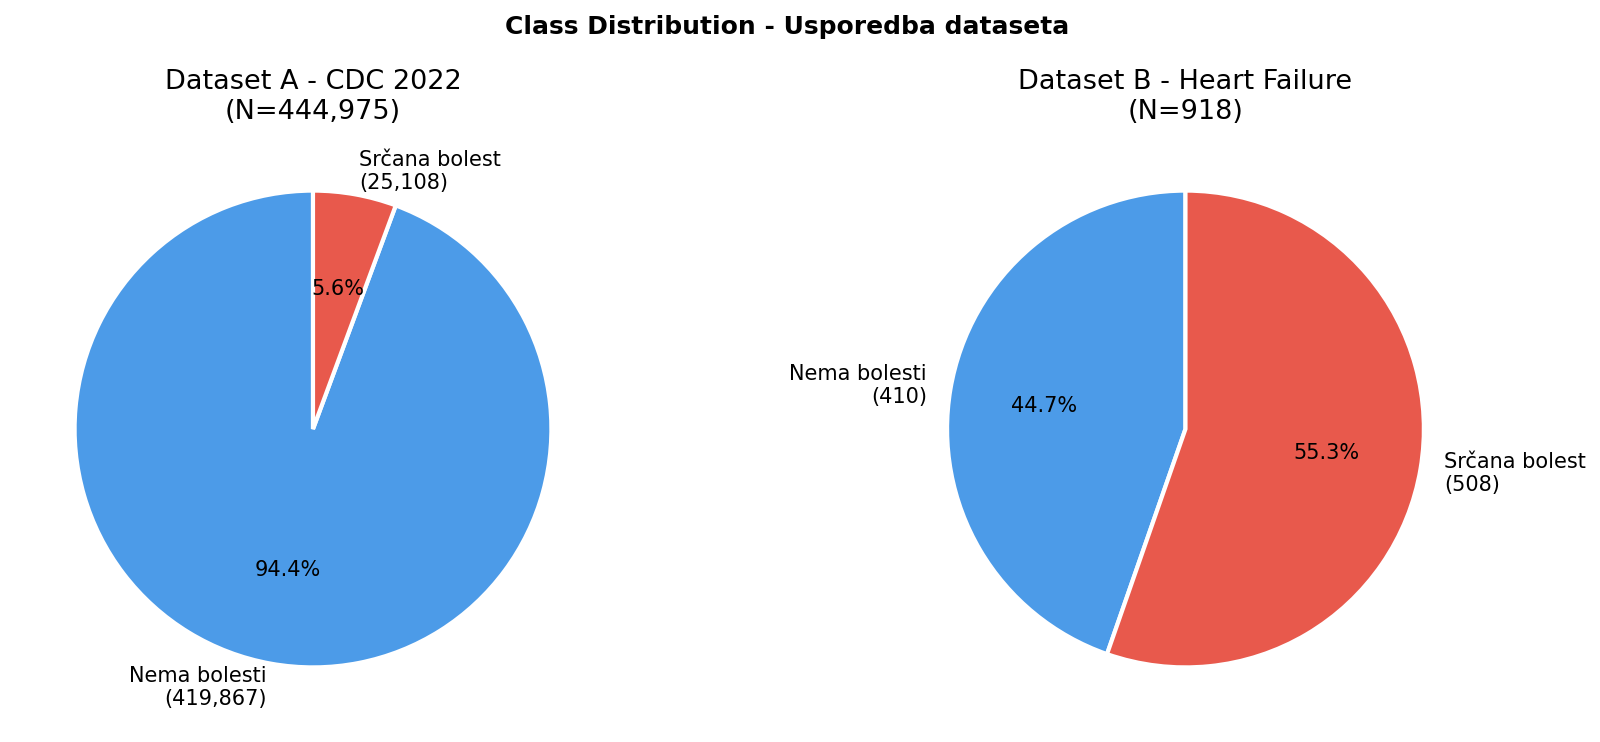


PREPROCESSING SUMMARY
Karakteristika                            Dataset A    Dataset B
--------------------------------------------------------------
Originalnih uzoraka                         445,132          918
Nakon čišćenja                              444,975          918
Feature-a                                        39           11
Train uzoraka (originalno)                  355,980          734
Train uzoraka (nakon SMOTE)                 671,788          734
Test uzoraka                                 88,995          184
SMOTE primijenjen                              True        False
Tip dataseta                             Survey/CDC     Klinički
Target kolona                          HadHeartAttack HeartDisease


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, counts, n_total) in zip(axes, [
    ('Dataset A - CDC 2022', counts_a, len(df_a)),
    ('Dataset B - Heart Failure', counts_b, len(df_b))
]):
    colors_pie = [PALETTE['negative'], PALETTE['positive']]
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=[f'Nema bolesti\n({counts.values[0]:,})' if i == 0
                else f'Srčana bolest\n({counts.values[1]:,})'
                for i in range(len(counts))],
        autopct='%1.1f%%',
        colors=colors_pie[:len(counts)],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    ax.set_title(f'{name}\n(N={n_total:,})')

plt.suptitle('Class Distribution - Usporedba dataseta', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/COMPARISON_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabelarni summary
print(f'\n{"="*65}')
print(f'PREPROCESSING SUMMARY')
print(f'{"="*65}')
print(f'{"Karakteristika":<38} {"Dataset A":>12} {"Dataset B":>12}')
print(f'{"-"*62}')
print(f'{"Originalnih uzoraka":<38} {df_a_raw.shape[0]:>12,} {df_b_raw.shape[0]:>12,}')
print(f'{"Nakon čišćenja":<38} {df_a.shape[0]:>12,} {df_b.shape[0]:>12,}')
print(f'{"Feature-a":<38} {X_a.shape[1]:>12} {X_b.shape[1]:>12}')
print(f'{"Train uzoraka (originalno)":<38} {X_a_train.shape[0]:>12,} {X_b_train.shape[0]:>12,}')
print(f'{"Train uzoraka (nakon SMOTE)":<38} {X_a_train_res.shape[0]:>12,} {X_b_train_res.shape[0]:>12,}')
print(f'{"Test uzoraka":<38} {X_a_test_sc.shape[0]:>12,} {X_b_test_sc.shape[0]:>12,}')
print(f'{"SMOTE primijenjen":<38} {str(SMOTE_APPLIED_A):>12} {str(SMOTE_APPLIED_B):>12}')
print(f'{"Tip dataseta":<38} {"Survey/CDC":>12} {"Klinički":>12}')
print(f'{"Target kolona":<38} {TARGET_A:>12} {TARGET_B:>12}')
print(f'{"="*65}')

## 5. Čuvanje preprocessovanih podataka 

In [28]:
import pickle

preprocessing_output = {
    # Dataset A
    'X_a_train': X_a_train_res,
    'X_a_test': X_a_test_sc,
    'y_a_train': y_a_train_res,
    'y_a_test': y_a_test,
    'feature_names_a': feature_cols_a,
    'scaler_a': scaler_a,
    'target_a': TARGET_A,

    # Dataset B
    'X_b_train': X_b_train_res,
    'X_b_test': X_b_test_sc,
    'y_b_train': y_b_train_res,
    'y_b_test': y_b_test,
    'feature_names_b': feature_cols_b,
    'scaler_b': scaler_b,
    'target_b': TARGET_B,
}

with open('data/processed/preprocessing_output.pkl', 'wb') as f:
    pickle.dump(preprocessing_output, f)

print('Sačuvano: data/processed/preprocessing_output.pkl')
print()
print('S3 - Preprocessing & EDA ZAVRŠEN!')

Sačuvano: data/processed/preprocessing_output.pkl

S3 - Preprocessing & EDA ZAVRŠEN!
